# 4.3 Redes neuronales convolucionales

Las redes neuronales convolucionales (CNN) son el caballo de batalla del aprendizaje profundo sobre datos estructurados: imágenes, espectrogramas y series de tiempo. Este cuaderno cubre:

1. Convoluciones y *kernels* (núcleos), aplicados a mano sobre una imagen.
2. Los bloques constructivos de una CNN: convolución, activación, *pooling* (submuestreo), capas totalmente conectadas.
3. LeNet-5 sobre los dígitos de MNIST, escrita en PyTorch — el calentamiento.
4. Una CNN 2D que hace regresión de tendencias de calentamiento a partir de un campo climático sintético en malla, contra un modelo de referencia de mínimos cuadrados.
5. Un detector de sismos con CNN 1D entrenado con sismogramas sintéticos, su piso de detección en función de la relación señal-ruido, y el detector clásico STA/LTA medido en las mismas trazas.
6. Una prueba de realidad: el detector entrenado con sintéticos, evaluado sobre formas de onda reales y etiquetadas de miniPNW.
7. Cómo traducir a código funcional la tabla de arquitectura de una red publicada.


🖥️ [**Diapositivas — Sesión 22 (vie 20 nov)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec22_convolution_detector.html)

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchinfo
from scipy.signal import convolve2d
from skimage import data

# Device-agnostic setup: CUDA GPU, Apple silicon (MPS), or CPU.
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")

Using device: mps


## 0. Para repasar

A esta altura, usted debería comprender:

- El perceptrón
- El papel de las *funciones de activación*
- Por qué y cómo implementar un *descenso de gradiente* simple
- Las funciones de pérdida
- El armado de lotes (*batching*)
- Los perceptrones multicapa


## 1. Convoluciones

Igual que en los perceptrones y los perceptrones multicapa, cada elemento de una CNN recibe entradas, calcula un producto punto y pasa ese producto por una función de activación. La diferencia es que una CNN aplica el *mismo* conjunto pequeño de pesos, llamado **kernel** (núcleo), en todas las posiciones de la entrada. Estas redes funcionan bien sobre datos estructurados 1D, 2D y 3D, como series de tiempo e imágenes.

Como su nombre lo indica, las CNN se basan en **convoluciones**:

$(f*g)(x)= \int\limits^{+\infty}_{\tau=-\infty}f(\tau)g(x-\tau)d\tau$

donde $g$ es la entrada, $f$ es el **kernel** de la convolución y $\tau$ es una variable muda.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/6a/Convolution_of_box_signal_with_itself2.gif" style="display:block;">

Para funciones discretas, simplemente se suma:

$(f*g)(x)= \sum\limits^{+\infty}_{\tau=-\infty} f(\tau)g(x-\tau)$

La convolución se extiende a varias dimensiones.

<img src="https://upload.wikimedia.org/wikipedia/commons/1/19/2D_Convolution_Animation.gif" style="display:block; border: 1px solid #555;">

Por ejemplo, considere el **filtro de media** (aquí, para un kernel de 3 x 3):

\begin{bmatrix}
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\end{bmatrix}


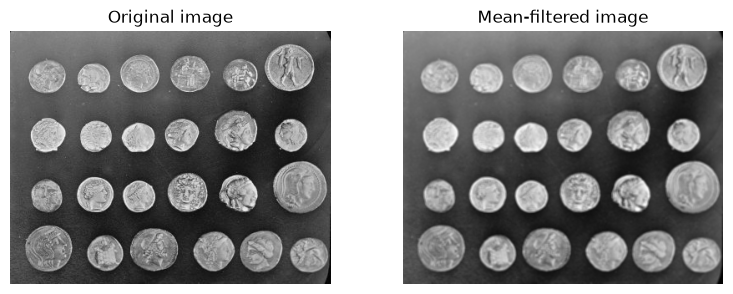

In [2]:
# Load an example image from scikit-image
image = data.coins()

# Kernel size
filterDimension = 3

# Define a mean filter
mean_filter = np.ones((filterDimension, filterDimension)) / (filterDimension * filterDimension)

# Apply the mean filter to the image using convolution
filtered_image = convolve2d(image, mean_filter, mode='same', boundary='symm')

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original image')
ax[1].imshow(filtered_image, cmap='gray')
ax[1].set_title('Mean-filtered image')
for a in ax:
    a.axis('off')
fig.tight_layout()

El filtro de media difumina. Otros kernels detectan estructura. Los **filtros de Sobel** aproximan el gradiente de la imagen y responden a los bordes:

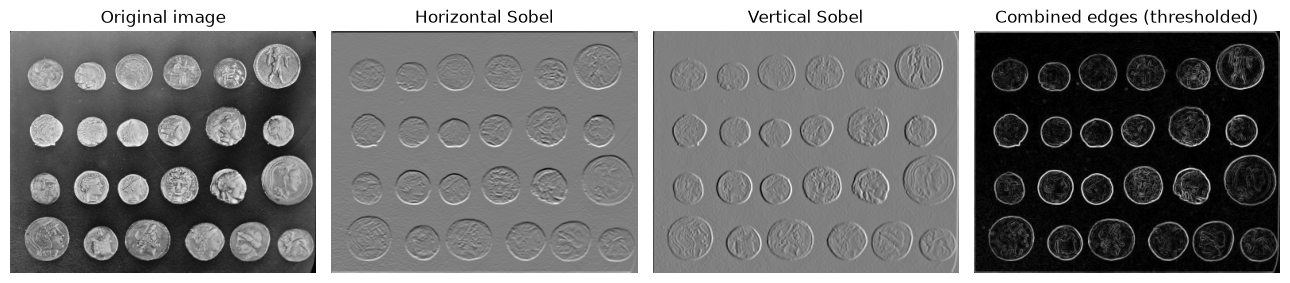

In [3]:
# Sobel filters
sobel_filter_horizontal = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

sobel_filter_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Apply the Sobel filters to the image
result_horizontal = convolve2d(image, sobel_filter_horizontal)
result_vertical = convolve2d(image, sobel_filter_vertical)

# Combine the horizontal and vertical edges to get the overall edges
edges = np.sqrt(result_horizontal**2 + result_vertical**2)

# Thresholding to accentuate the edges
threshold = 10
edges[edges < threshold] = 0

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original image')
axes[1].imshow(result_horizontal, cmap='gray')
axes[1].set_title('Horizontal Sobel')
axes[2].imshow(result_vertical, cmap='gray')
axes[2].set_title('Vertical Sobel')
axes[3].imshow(edges, cmap='gray')
axes[3].set_title('Combined edges (thresholded)')
for a in axes:
    a.axis('off')
fig.tight_layout()

La gracia de una CNN es que *no* usa kernels diseñados a mano como estos. **Aprende** los pesos del kernel a partir de los datos, por descenso de gradiente. Las primeras capas a menudo terminan aprendiendo detectores de bordes por sí solas.

**Ejercicio 1.** Cambie `filterDimension` de 3 a 15 en la celda del filtro de media. ¿Qué pasa con las monedas, y por qué?

```{admonition} Solución
:class: dropdown
Un filtro de media de 15 x 15 promedia sobre un vecindario mucho más grande, así que la imagen queda fuertemente difuminada y los rasgos pequeños (la textura dentro de las monedas, los espacios entre ellas) desaparecen. El tamaño del kernel fija la escala espacial de los rasgos a los que responde una convolución.
```


## 2. Armar una CNN

La arquitectura de una CNN comprende clásicamente:

1. Una capa **convolucional**
2. Una capa de **activación**
3. Una capa de ***pooling*** (submuestreo)
4. Una capa **totalmente conectada**


### 2.1 La capa convolucional

*Aquí consideramos una CNN que recibe imágenes y devuelve alguna salida.*

Aspectos de esta capa:

**Entradas**: en el caso de las convoluciones 2D, tres dimensiones: *alto, ancho, profundidad*.

**Filtros**: los kernels de convolución, cada uno con un sesgo y un peso por cada elemento del kernel. La salida de un filtro es un **mapa de características** (*feature map*). En general, el número de filtros es mayor que la profundidad de la entrada. El **tamaño del kernel** suele ser cuadrado, pero no tiene por qué serlo.

***Stride*** (paso): el tamaño del paso con el que se desplaza el filtro.

***Padding*** (relleno): valores agregados a los bordes de la entrada.

![Convolution Kernel](https://d2l.ai/_images/correlation.svg)

*Convolución con ventana de kernel (Fig. 7.2.1 de Dive into Deep Learning).*

En el ejemplo de arriba, el valor de salida superior izquierdo es 0×0 + 1×1 + 3×2 + 4×3 = 19. Repetimos el proceso hasta llenar todos los elementos del mapa de salida, y lo repetimos para cada filtro.

<sub>*Una buena lección sobre CNN es la [hoja de referencia de CS230](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks) de Stanford.*</sub>

¿Cómo interpretaría el siguiente código?


In [4]:
# pytorch version
torch.nn.Conv2d(in_channels=3, out_channels=64, kernel_size=6)

Conv2d(3, 64, kernel_size=(6, 6), stride=(1, 1))

Esta capa toma una entrada con 3 canales (por ejemplo, una imagen RGB), aplica 64 filtros de tamaño 6 x 6 (cada uno abarca los 3 canales de entrada) y produce 64 mapas de características.

### 2.2 La capa de activación

La capa convolucional va seguida de una capa de activación. Esta capa aplica una *función de activación*, como **ReLU (unidad lineal rectificada)**, a las salidas de la convolución.


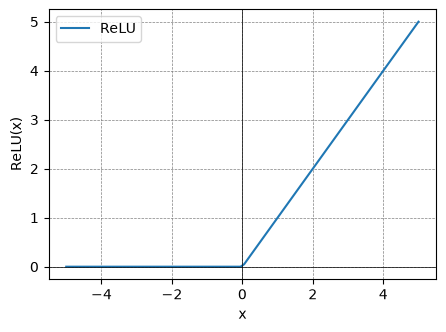

In [5]:
# Define the ReLU function
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-5, 5, 100)
y_relu = relu(x)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(x, y_relu, label='ReLU')
ax.set_xlabel('x')
ax.set_ylabel('ReLU(x)')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.legend()
plt.show()

### 2.3 La capa de pooling

La capa de *pooling* *submuestrea* los mapas de características. Al combinar valores, el *pooling* reduce el tamaño del modelo y lo hace menos sensible a pequeños desplazamientos de la entrada.

Las capas de ***max pooling*** toman el valor máximo dentro de un vecindario dado (fijado por el *tamaño de pooling*).

![](https://raw.githubusercontent.com/d2l-ai/d2l-en/master/img/pooling.svg)

### 2.4 La capa totalmente conectada

Finalmente, incluimos una capa totalmente conectada (cada entrada conectada con cada salida). Para clasificación, las CNN típicamente terminan con una **softmax** que transforma las salidas de la última capa totalmente conectada en probabilidades de clase (valores entre 0 y 1 que suman 1).

### 2.5 Algunas notas

En la capa convolucional, las neuronas no están conectadas a todas las partes de los datos de entrada.

Una capa densa aprende patrones globales. Una capa de convolución aprende patrones locales y es **equivariante a traslaciones**: si se desplaza la entrada, el mapa de características se desplaza con ella, de modo que un patrón aprendido en una parte de la imagen (o de la serie de tiempo) se detecta en cualquier otra. La **invariancia a traslaciones** aproximada de una CNN completa — la misma predicción esté donde esté el patrón — proviene de las capas de *pooling*, que descartan la posición al submuestrear; el detector 1D de la sección 5 obtiene su tolerancia a desplazamientos de su *pooling* promedio global. Las CNN también aprenden **patrones jerárquicos**: una primera capa aprende un patrón local, una segunda capa combina las características locales en características de escala más amplia.

### 2.6 Aparte: vocabulario de segmentación de imágenes

La clasificación asigna una etiqueta a la imagen completa. La segmentación asigna etiquetas al nivel del píxel, y viene en tres variantes. Una ilustración estándar es una escena callejera mostrada de tres maneras: la segmentación **semántica** colorea cada píxel por clase (calle, cielo, persona, automóvil) sin separar individuos; la segmentación por **instancias** delinea cada objeto individual (esta persona, aquel automóvil) por separado; la segmentación **panóptica** combina ambas, etiquetando cada píxel por clase mientras mantiene distintas las instancias de los objetos.


## 3. LeNet-5 sobre MNIST

MNIST es el «hola mundo» del aprendizaje profundo: pequeño, limpio y en nada parecido a un conjunto de datos de geociencias. Lo usamos como calentamiento, para dejar bien afinada la mecánica de entrenamiento en un problema donde nada más puede salir mal; la carga geocientífica empieza en la sección 4. Construimos ahora la arquitectura LeNet-5 (LeCun et al., 1998), una de las primeras CNN exitosas, y la entrenamos para clasificar dígitos manuscritos de MNIST. La red es una pila secuencial de 2 capas convolucionales y 3 capas totalmente conectadas. Una representación gráfica común:

![](https://d2l.ai/_images/lenet.svg)

### 3.1 Cargar los datos

Usamos `torchvision` para descargar MNIST. El conjunto de entrenamiento completo tiene 60 000 imágenes; para mantener rápido este cuaderno entrenamos con un subconjunto de 6 000 y evaluamos con 1 500 imágenes de prueba. En su propia máquina puede aumentar estos números (y el número de épocas) para obtener mejor exactitud.


In [6]:
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets
from torchvision.transforms import Compose, Normalize, ToTensor

data_root = os.path.expanduser("~/.cache/mlgeo-mnist")
transform = Compose([ToTensor(), Normalize([0.5], [0.5])])

train_full = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_full = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

# Subsets for speed
train_set = Subset(train_full, range(6000))
test_set = Subset(test_full, range(1500))

loaded_train = DataLoader(train_set, batch_size=64, shuffle=True)
loaded_test = DataLoader(test_set, batch_size=256)

X, y = next(iter(loaded_train))
print("One batch of images:", X.shape, "labels:", y.shape)

One batch of images: torch.Size([64, 1, 28, 28]) labels: torch.Size([64])


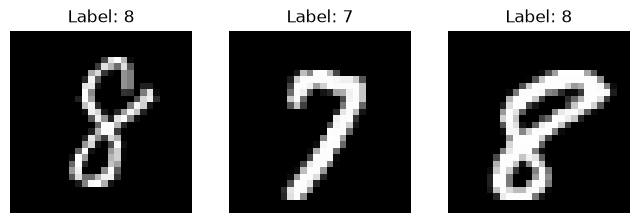

In [7]:
# Display 3 images from one batch
images, labels = next(iter(loaded_train))
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for i in range(3):
    axes[i].imshow(images[i].numpy().squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')
plt.show()

### 3.2 El modelo

Escribimos LeNet-5 como una pila `torch.nn.Sequential`. El módulo `Reshape` se asegura de que la entrada tenga la forma `(batch, channels, height, width)`, que es lo que espera `Conv2d`.


In [8]:
class Reshape(torch.nn.Module):
    def forward(self, x):
        return x.view(-1, 1, 28, 28)

model_lenet = torch.nn.Sequential(
    Reshape(),
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10),
)

In [9]:
# Walk a dummy input through the network and watch the shape change
Xd = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
print('Initial input shape: \t', Xd.shape)
for layer in model_lenet:
    Xd = layer(Xd)
    print(layer.__class__.__name__, 'output shape: \t', Xd.shape)

Initial input shape: 	 torch.Size([1, 1, 28, 28])
Reshape output shape: 	 torch.Size([1, 1, 28, 28])
Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [10]:
torchinfo.summary(model_lenet, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Reshape: 1-1                           [1, 1, 28, 28]            --
├─Conv2d: 1-2                            [1, 6, 28, 28]            156
├─Sigmoid: 1-3                           [1, 6, 28, 28]            --
├─AvgPool2d: 1-4                         [1, 6, 14, 14]            --
├─Conv2d: 1-5                            [1, 16, 10, 10]           2,416
├─Sigmoid: 1-6                           [1, 16, 10, 10]           --
├─AvgPool2d: 1-7                         [1, 16, 5, 5]             --
├─Flatten: 1-8                           [1, 400]                  --
├─Linear: 1-9                            [1, 120]                  48,120
├─Sigmoid: 1-10                          [1, 120]                  --
├─Linear: 1-11                           [1, 84]                   10,164
├─Sigmoid: 1-12                          [1, 84]                   --
├─L

### 3.3 Configuración del entrenamiento

Necesitamos elegir algunos parámetros de entrenamiento:

* La métrica de error: exactitud
* La función de pérdida: *entropía cruzada* para clasificación multiclase
* El tamaño de lote (64 aquí)
* El número de épocas (2 aquí, por rapidez)
* El optimizador: *Adam*, una variante del descenso de gradiente estocástico que usa estimaciones del primer y segundo momento del gradiente para adaptar la tasa de aprendizaje de cada peso

La función de entrenamiento siguiente es genérica: acepta cualquier modelo y cualquier par de cargadores de datos, así que la reutilizaremos en la sección 5. Mueve cada lote a `device`, ejecuta la pasada hacia adelante (*forward pass*), retropropaga la pérdida y actualiza los pesos. Después de cada época evalúa la pérdida y la exactitud en el cargador de validación (con los gradientes desactivados).

La función también conserva un **punto de control** (*checkpoint*): una copia de los pesos de la época con la mejor exactitud de validación, restaurada al final. El entrenamiento estocástico no mejora monótonamente, así que la última época no siempre es la mejor. En producción usted escribiría el *checkpoint* a disco con `torch.save({'state_dict': model.state_dict()}, 'checkpoint.pt')`; aquí lo mantenemos en memoria.


In [11]:
def train_model(model, train_loader, val_loader, n_epochs=2, learning_rate=1e-3, device=device):
    """Train a classifier, record per-epoch metrics, and restore the best-validation checkpoint."""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = -1.0, None

    for epoch in range(n_epochs):
        # --- training pass ---
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs = inputs.float().to(device)
            labels = labels.long().to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        history["train_loss"].append(running_loss / len(train_loader))

        # --- validation pass (no gradients) ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.float().to(device)
                labels = labels.long().to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)
        history["val_loss"].append(val_loss / len(val_loader))
        history["val_acc"].append(100 * correct / total)

        print(f"[Epoch {epoch + 1}] train loss: {history['train_loss'][-1]:.3f} - "
              f"val loss: {history['val_loss'][-1]:.3f} - val accuracy: {history['val_acc'][-1]:.1f}%")

        # checkpoint: remember the weights of the best epoch so far
        if history["val_acc"][-1] > best_acc:
            best_acc = history["val_acc"][-1]
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    print(f"Restored checkpoint with best validation accuracy: {best_acc:.1f}%")
    return history

In [12]:
torch.manual_seed(42)
history_lenet = train_model(model_lenet, loaded_train, loaded_test, n_epochs=2, learning_rate=0.005)

[Epoch 1] train loss: 2.272 - val loss: 1.948 - val accuracy: 37.1%


[Epoch 2] train loss: 0.927 - val loss: 0.544 - val accuracy: 84.1%
Restored checkpoint with best validation accuracy: 84.1%


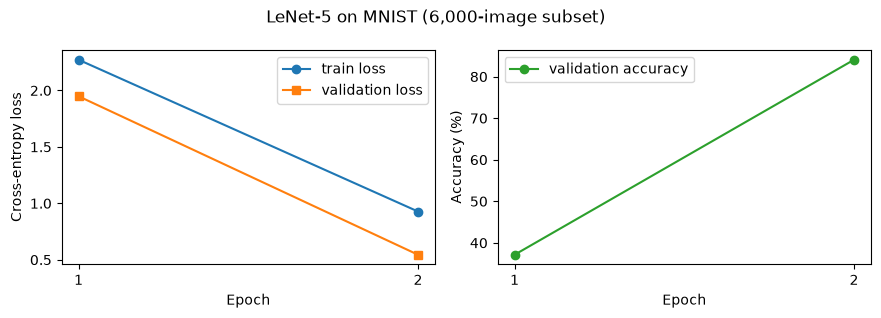

In [13]:
epochs = np.arange(1, len(history_lenet["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(epochs, history_lenet["train_loss"], marker='o', label='train loss')
ax[0].plot(epochs, history_lenet["val_loss"], marker='s', label='validation loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Cross-entropy loss')
ax[0].set_xticks(epochs)
ax[0].legend()
ax[1].plot(epochs, history_lenet["val_acc"], marker='o', color='tab:green', label='validation accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_xticks(epochs)
ax[1].legend()
fig.suptitle('LeNet-5 on MNIST (6,000-image subset)')
fig.tight_layout()

Dos épocas con un subconjunto de 6 000 imágenes ponen en marcha la LeNet con sigmoides, pero la dejan lejos de su techo. Con las 60 000 imágenes completas y ~10 épocas esta arquitectura alcanza cerca del 99 % de exactitud; pruébelo en su propia máquina. Cambiar las sigmoides por ReLU también acelera considerablemente el entrenamiento.


Con eso queda hecho el calentamiento. La receta — tensores de entrada, bloques de convolución, una cabeza, un bucle de entrenamiento — pasa ahora a datos que se parecen a los nuestros.

## 4. Una CNN 2D sobre un campo geocientífico en malla

Los campos en malla — temperatura de reanálisis, radiancias satelitales, salidas de modelos — son los datos 2D nativos de las geociencias, y no se comportan en nada como las imágenes de dígitos. Usamos el generador del curso `mlgeo_synth.climate_field`: anomalías mensuales de temperatura en una malla latitud-longitud de 40 x 80, con un ciclo estacional antisimétrico entre hemisferios, un modo zonal lento, ruido meteorológico correlacionado espacialmente y una tendencia lineal de calentamiento amplificada en las latitudes altas del norte. Como el generador es nuestro, la tendencia local verdadera de cada píxel se conoce con exactitud.

**La tarea.** Hacer regresión de la tendencia local de calentamiento, en °C por década, a partir de parches de 8 x 8 píxeles. Cada parche entra a la red como una imagen de 30 canales: 30 mapas de anomalías medias anuales, un canal por año. Canales-como-tiempo es el truco estándar para alimentar con un campo que evoluciona en el tiempo a una CNN 2D.

**La división.** Todos los parches de un mismo campo comparten el valor de tendencia global de ese campo, así que los parches de un mismo campo nunca deben quedar a ambos lados de la frontera entrenamiento/prueba — la doctrina de la división por grupos del capítulo 3.8, aplicada. Generamos 24 campos con tendencias muestreadas uniformemente entre 0.05 y 0.5 °C/década, y dividimos por campo: 18 para entrenamiento, 6 para prueba.

**Primero el modelo de referencia.** Promediar espacialmente cada parche y ajustar una recta a sus 30 medias anuales — una llamada a `np.polyfit`. Si la CNN no puede superar eso, queremos saberlo.

In [14]:
import mlgeo_synth

n_fields, n_years, patch = 24, 30, 8
rng_f = np.random.default_rng(0)
true_trends = rng_f.uniform(0.05, 0.5, n_fields)  # one global trend per field, deg C / decade

X_patches, y_trend, field_id = [], [], []
for fi, trend in enumerate(true_trends):
    field, truth = mlgeo_synth.climate_field(n_lat=40, n_lon=80, n_months=12 * n_years,
                                             trend_c_per_decade=float(trend), seed=100 + fi)
    annual = field.reshape(n_years, 12, 40, 80).mean(axis=1)  # (30, 40, 80) annual means
    # the generator amplifies the trend poleward in the north:
    # local trend = global trend x (1 + 1.5 * max(latitude in radians, 0))
    amp = 1.0 + 1.5 * np.clip(np.deg2rad(truth["lat"]), 0, None)
    local_trend = trend * amp
    for r in range(0, 40, patch):
        for c in range(0, 80, patch):
            X_patches.append(annual[:, r:r + patch, c:c + patch])
            y_trend.append(local_trend[r:r + patch].mean())
            field_id.append(fi)

X_patches = np.array(X_patches, dtype=np.float32)
y_trend = np.array(y_trend, dtype=np.float32)
field_id = np.array(field_id)
print("patches:", X_patches.shape,
      f"| true local trends {y_trend.min():.2f} to {y_trend.max():.2f} C/decade")

train_mask = field_id < 18  # grouped split: fields 0-17 train, 18-23 test
Xc_train, yc_train = X_patches[train_mask], y_trend[train_mask]
Xc_test, yc_test = X_patches[~train_mask], y_trend[~train_mask]
print(f"train: {len(Xc_train)} patches from 18 fields | test: {len(Xc_test)} patches from 6 fields")

# Classical baseline: least-squares slope of the patch-mean annual series
years = np.arange(n_years)

def lsq_trend(patches):
    """Least-squares warming trend (deg C / decade) of each patch's spatial-mean series."""
    series = patches.mean(axis=(2, 3))          # (n, 30)
    slopes = np.polyfit(years, series.T, 1)[0]  # deg C / year
    return slopes * 10.0

mae_lsq = np.abs(lsq_trend(Xc_test) - yc_test).mean()
print(f"least-squares baseline, test MAE: {mae_lsq:.3f} C/decade")

patches: (1200, 30, 8, 8) | true local trends 0.05 to 1.36 C/decade
train: 900 patches from 18 fields | test: 300 patches from 6 fields
least-squares baseline, test MAE: 0.083 C/decade


In [15]:
torch.manual_seed(0)
model_clim = nn.Sequential(
    nn.Conv2d(n_years, 32, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(32, 1),
)
print(f"parameters: {sum(p.numel() for p in model_clim.parameters()):,}")

clim_loader = DataLoader(TensorDataset(torch.from_numpy(Xc_train), torch.from_numpy(yc_train)),
                         batch_size=64, shuffle=True)
model_clim.to(device)
opt = torch.optim.Adam(model_clim.parameters(), lr=1e-3)
mse = nn.MSELoss()
for epoch in range(30):
    model_clim.train()
    running = 0.0
    for xb, yb in clim_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = mse(model_clim(xb).squeeze(1), yb)
        loss.backward()
        opt.step()
        running += loss.item() * len(xb)
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1:2d}: train MSE {running / len(Xc_train):.4f} (C/decade)^2")

parameters: 17,953


epoch 10: train MSE 0.0008 (C/decade)^2


epoch 20: train MSE 0.0001 (C/decade)^2


epoch 30: train MSE 0.0001 (C/decade)^2


test MAE (C/decade)  naive least squares: 0.083   + known mode: 0.009   2-D CNN: 0.008


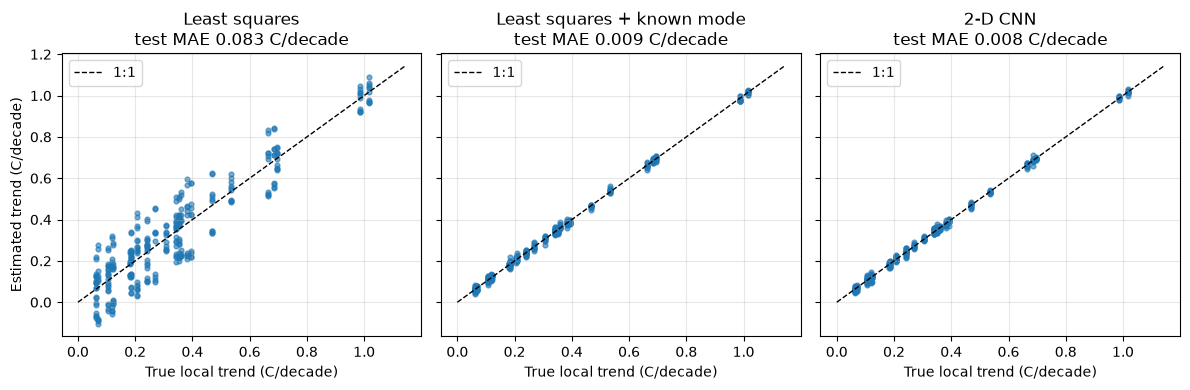

In [16]:
model_clim.eval()
with torch.no_grad():
    pred_cnn = model_clim(torch.from_numpy(Xc_test).to(device)).squeeze(1).cpu().numpy()
pred_lsq = lsq_trend(Xc_test)
mae_cnn = np.abs(pred_cnn - yc_test).mean()

# A fairer classical opponent: the generator's slow interannual mode (a 5-year cycle,
# identical in every field) aliases into a straight-line fit. Adding that known mode
# as one extra regressor is all it takes.
zon_annual = np.sin(2 * np.pi * np.arange(12 * n_years) / 60.0).reshape(n_years, 12).mean(axis=1)
G = np.column_stack([np.ones(n_years), years, zon_annual])

def lsq_trend_modeaware(patches):
    """Trend (deg C / decade) with the known interannual mode as a co-regressor."""
    series = patches.mean(axis=(2, 3))
    coef, *_ = np.linalg.lstsq(G, series.T, rcond=None)
    return coef[1] * 10.0

pred_lsq2 = lsq_trend_modeaware(Xc_test)
mae_lsq2 = np.abs(pred_lsq2 - yc_test).mean()

lims = [0, 1.05 * max(yc_test.max(), pred_cnn.max(), pred_lsq.max())]
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for a, pred, name, mae in [(ax[0], pred_lsq, 'Least squares', mae_lsq),
                           (ax[1], pred_lsq2, 'Least squares + known mode', mae_lsq2),
                           (ax[2], pred_cnn, '2-D CNN', mae_cnn)]:
    a.scatter(yc_test, pred, s=12, alpha=0.6)
    a.plot(lims, lims, 'k--', lw=1, label='1:1')
    a.set_xlabel('True local trend (C/decade)')
    a.set_title(f'{name}\ntest MAE {mae:.3f} C/decade')
    a.legend(loc='upper left')
    a.grid(alpha=0.3)
ax[0].set_ylabel('Estimated trend (C/decade)')
fig.tight_layout()
print(f"test MAE (C/decade)  naive least squares: {mae_lsq:.3f}   "
      f"+ known mode: {mae_lsq2:.3f}   2-D CNN: {mae_cnn:.3f}")

Tanto el estimador aprendido como el clásico recuperan la estructura de tendencia amplificada hacia los polos, pero los márgenes merecen una lectura cuidadosa. El ajuste ingenuo de una recta queda en 0.083 °C/década de MAE mientras que la CNN llega a 0.008 — un factor de diez. Antes de atribuirle magia a la red, pregunte qué aprendió. El generador superpone un modo zonal lento de 5 años en cada campo, y sobre un registro de 30 años ese modo no se promedia y desaparece en un ajuste de recta: se cuela en la pendiente por solapamiento (*aliasing*). El panel central le da al estimador clásico esa pieza de física — el modo conocido como un único regresor adicional — y su MAE cae a 0.009 °C/década, estadísticamente indistinguible de la CNN.

Así que la lección honesta: la victoria de la CNN sobre los mínimos cuadrados *ingenuos* es en realidad una victoria sobre un modelo de referencia mal especificado. Lo que la red extrajo de 18 campos de entrenamiento es el modo interanual de confusión — y pudo hacerlo solo porque ese modo es idéntico en todos los campos sintéticos. Los modelos profundos se ganan el pan cuando los factores de confusión son desconocidos o imposibles de escribir; cuando usted puede escribirlos, el ajuste clásico con los regresores correctos iguala a la CNN a una fracción del costo. Note también lo que nos compró la división por grupos: si los parches de un campo hubieran caído a ambos lados de la frontera, la CNN podría haber memorizado el ruido específico de cada campo y la comparación no tendría sentido. El detector de sismos de abajo recibe exactamente el mismo trato frente a su propio modelo de referencia clásico.

## 5. Un detector de sismos con CNN 1D

Las convoluciones no se limitan a las imágenes. Los sismólogos usan CNN 1D para escanear sismogramas continuos y clasificar ventanas cortas como «sismo» o «ruido». ConvNetQuake (Perol et al., 2018) fue un ejemplo temprano; los marcadores de fases (*phase pickers*) modernos, como EQTransformer y PhaseNet, siguen la misma idea a mayor escala.

Los conjuntos de formas de onda reales son grandes y sus etiquetas son imperfectas. Aquí usamos en cambio el generador de sismogramas sintéticos del curso, `mlgeo_synth`. Cada traza de evento contiene una llegada P seguida de una llegada S más fuerte, sobre ruido coloreado; cada traza de ruido contiene solo ruido coloreado. Como controlamos el generador, cada traza viene con metadatos exactos: tiempos de llegada y relación señal-ruido (SNR, definida como la amplitud pico de la señal dividida por la desviación estándar del ruido).

### 5.1 Generar e inspeccionar los datos


In [17]:
import mlgeo_synth

fs = 100.0  # sampling rate (Hz)
X_seis, y_seis, metas = mlgeo_synth.seismogram_dataset(n_events=800, n_noise=800, fs=fs,
                                                       duration_s=30.0, seed=0)
print("X:", X_seis.shape, "- y:", y_seis.shape)
print("Class balance: %d events, %d noise" % ((y_seis == 1).sum(), (y_seis == 0).sum()))
print("Example event metadata:", {k: round(float(v), 2) for k, v in metas[0].items()})

X: (1600, 3000) - y: (1600,)
Class balance: 800 events, 800 noise
Example event metadata: {'t_p': 9.21, 't_s': 12.21, 'peak_amplitude': 0.5, 'snr': 0.58}


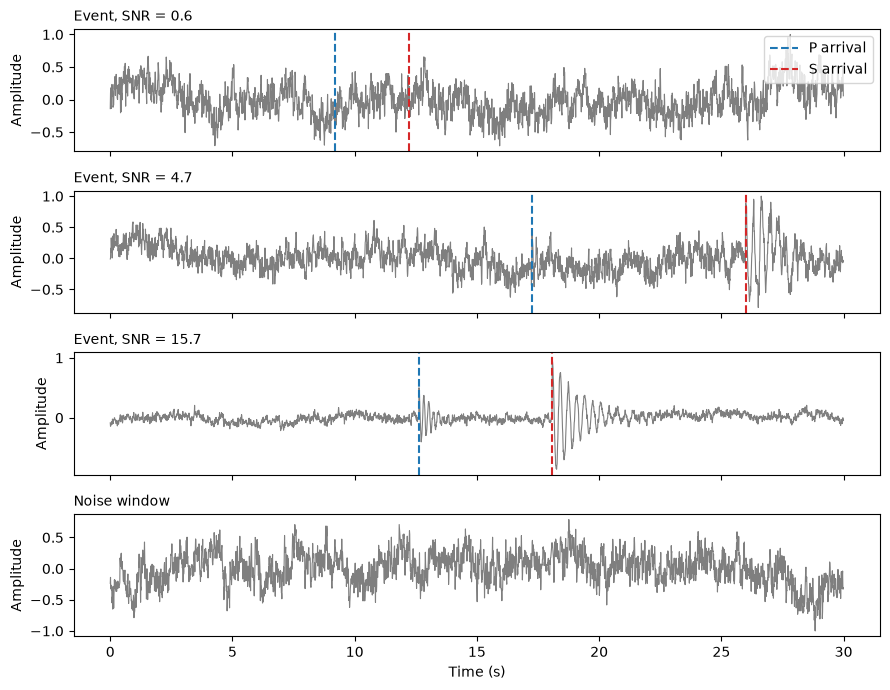

In [18]:
t = np.arange(X_seis.shape[1]) / fs
fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)

# three events with their P and S arrival times
event_idx = [0, 1, 2]
for ax, i in zip(axes[:3], event_idx):
    ax.plot(t, X_seis[i], color='tab:gray', linewidth=0.8)
    ax.axvline(metas[i]['t_p'], color='tab:blue', linestyle='--', label='P arrival')
    ax.axvline(metas[i]['t_s'], color='tab:red', linestyle='--', label='S arrival')
    ax.set_ylabel('Amplitude')
    ax.set_title(f"Event, SNR = {metas[i]['snr']:.1f}", fontsize=10, loc='left')
axes[0].legend(loc='upper right')

# one noise-only window
noise_idx = np.where(y_seis == 0)[0][0]
axes[3].plot(t, X_seis[noise_idx], color='tab:gray', linewidth=0.8)
axes[3].set_title('Noise window', fontsize=10, loc='left')
axes[3].set_ylabel('Amplitude')
axes[3].set_xlabel('Time (s)')
fig.tight_layout()

Los eventos de baja SNR son difíciles de ver a simple vista. Ese es exactamente el régimen donde queremos saber cómo se comporta un detector.

Antes de entrenar estandarizamos cada traza (le quitamos su media y la dividimos por su desviación estándar). Esto es importante: sin ello, la red podría clasificar solo por la amplitud absoluta en lugar de por la forma de la onda.


In [19]:
from sklearn.model_selection import train_test_split

def standardize(X):
    """Per-trace standardization: zero mean, unit standard deviation."""
    X = X - X.mean(axis=1, keepdims=True)
    return X / (X.std(axis=1, keepdims=True) + 1e-10)

Xn = standardize(X_seis).astype(np.float32)

# 70% train, 15% validation, 15% test
X_train, X_tmp, y_train, y_tmp = train_test_split(Xn, y_seis, test_size=0.3,
                                                  random_state=42, stratify=y_seis)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                                random_state=42, stratify=y_tmp)

def make_loader(X, y, batch_size, shuffle):
    # unsqueeze(1) adds the channel dimension: (batch, 1, n_samples)
    ds = TensorDataset(torch.from_numpy(X).unsqueeze(1), torch.from_numpy(y).long())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, 64, shuffle=True)
val_loader = make_loader(X_val, y_val, 256, shuffle=False)
test_loader = make_loader(X_test, y_test, 256, shuffle=False)
print(f"train {len(X_train)}, val {len(X_val)}, test {len(X_test)}")

train 1120, val 240, test 240


### 5.2 El modelo

El análogo 1D de la CNN de imágenes: tres bloques de `Conv1d` &rarr; `ReLU` &rarr; `MaxPool1d`, luego un `AdaptiveAvgPool1d` que promedia cada mapa de características hasta un solo valor, y una cabeza lineal con 2 salidas (ruido, evento). El *pooling* promedio global mantiene bajo el número de parámetros y hace que el modelo sea independiente de la longitud de la entrada.


In [20]:
torch.manual_seed(1)
model_seis = nn.Sequential(
    nn.Conv1d(1, 8, kernel_size=7, padding=3), nn.ReLU(), nn.MaxPool1d(4),
    nn.Conv1d(8, 16, kernel_size=7, padding=3), nn.ReLU(), nn.MaxPool1d(4),
    nn.Conv1d(16, 32, kernel_size=7, padding=3), nn.ReLU(), nn.MaxPool1d(4),
    nn.AdaptiveAvgPool1d(1),
    nn.Flatten(),
    nn.Linear(32, 2),
)
torchinfo.summary(model_seis, input_size=(1, 1, 3000))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 2]                    --
├─Conv1d: 1-1                            [1, 8, 3000]              64
├─ReLU: 1-2                              [1, 8, 3000]              --
├─MaxPool1d: 1-3                         [1, 8, 750]               --
├─Conv1d: 1-4                            [1, 16, 750]              912
├─ReLU: 1-5                              [1, 16, 750]              --
├─MaxPool1d: 1-6                         [1, 16, 187]              --
├─Conv1d: 1-7                            [1, 32, 187]              3,616
├─ReLU: 1-8                              [1, 32, 187]              --
├─MaxPool1d: 1-9                         [1, 32, 46]               --
├─AdaptiveAvgPool1d: 1-10                [1, 32, 1]                --
├─Flatten: 1-11                          [1, 32]                   --
├─Linear: 1-12                           [1, 2]                    66
Total param

Menos de 5 000 parámetros, comparados con los ~62 000 de LeNet. Los modelos pequeños entrenan rápido y son difíciles de sobreajustar con 1 120 trazas de entrenamiento.

### 5.3 Entrenar y evaluar

Reutilizamos `train_model` de la sección 3. Doce épocas corren en unos pocos segundos; aumente el número de épocas en su propia máquina para exprimir unos puntos porcentuales más.


In [21]:
torch.manual_seed(1)
history_seis = train_model(model_seis, train_loader, val_loader, n_epochs=12, learning_rate=2e-3)

[Epoch 1] train loss: 0.693 - val loss: 0.684 - val accuracy: 50.0%


[Epoch 2] train loss: 0.672 - val loss: 0.637 - val accuracy: 75.4%
[Epoch 3] train loss: 0.600 - val loss: 0.521 - val accuracy: 77.9%


[Epoch 4] train loss: 0.505 - val loss: 0.543 - val accuracy: 71.7%
[Epoch 5] train loss: 0.496 - val loss: 0.430 - val accuracy: 85.8%


[Epoch 6] train loss: 0.468 - val loss: 0.414 - val accuracy: 84.2%
[Epoch 7] train loss: 0.429 - val loss: 0.406 - val accuracy: 87.5%


[Epoch 8] train loss: 0.411 - val loss: 0.377 - val accuracy: 85.8%
[Epoch 9] train loss: 0.419 - val loss: 0.384 - val accuracy: 82.1%


[Epoch 10] train loss: 0.388 - val loss: 0.363 - val accuracy: 87.9%
[Epoch 11] train loss: 0.392 - val loss: 0.390 - val accuracy: 82.1%


[Epoch 12] train loss: 0.376 - val loss: 0.432 - val accuracy: 72.1%
Restored checkpoint with best validation accuracy: 87.9%


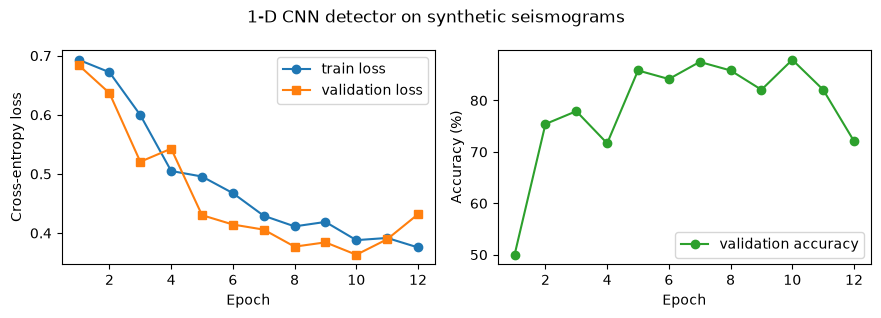

In [22]:
epochs = np.arange(1, len(history_seis["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(epochs, history_seis["train_loss"], marker='o', label='train loss')
ax[0].plot(epochs, history_seis["val_loss"], marker='s', label='validation loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Cross-entropy loss')
ax[0].legend()
ax[1].plot(epochs, history_seis["val_acc"], marker='o', color='tab:green', label='validation accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].legend()
fig.suptitle('1-D CNN detector on synthetic seismograms')
fig.tight_layout()

In [23]:
def predict(model, X, device=device):
    """Predicted class (0 noise, 1 event) for an array of standardized traces."""
    model.eval()
    with torch.no_grad():
        xb = torch.from_numpy(X.astype(np.float32)).unsqueeze(1).to(device)
        return model(xb).argmax(dim=1).cpu().numpy()

test_pred = predict(model_seis, X_test)
test_acc = (test_pred == y_test).mean()
print(f"Test accuracy: {100 * test_acc:.1f}%")

Test accuracy: 87.9%


Exactitud en los ochenta y tantos por ciento: muy por encima del azar, pero bien lejos de lo perfecto. ¿Por qué no 100 %? El conjunto de datos incluye deliberadamente eventos con SNR muy por debajo de 1, que son casi indetectables. Eso lleva a la pregunta de fondo: ¿*dónde* falla el detector?

### 5.4 La recompensa: el piso de detección, con un oponente clásico

Con sismogramas reales nunca se conoce la SNR verdadera de un evento perdido, así que el comportamiento de un detector a baja SNR es difícil de caracterizar. Los sintéticos nos dan la perilla que los datos reales nunca dan: podemos generar eventos a cualquier SNR que elijamos y medir exactamente dónde se quiebra la detección.

La CNN no tiene el escenario para ella sola. El disparador **STA/LTA** (promedio de corto plazo sobre promedio de largo plazo; Allen, 1978) — el detector clásico que ha corrido en los flujos de trabajo de los observatorios durante décadas, y cuyo piso de detección medimos con ondículas de Ricker en el [capítulo 2.10](../Chapter2-DataManipulation/2.10_synthetic_noise.ipynb) — corre sobre las *mismas trazas*, con la misma definición de SNR (amplitud pico de la señal sobre desviación estándar del ruido). Su umbral se fija de la manera honesta, solo a partir del ruido: el percentil 99 del STA/LTA pico sobre las 600 ventanas de solo ruido, lo que ancla su tasa de falsas alarmas en 1 % por construcción.

El barrido de abajo genera 60 eventos en cada uno de 10 valores de SNR desde alrededor de 0.3 hasta 20 (espaciados logarítmicamente), variando la magnitud, la distancia y la semilla del ruido, más 60 ventanas de solo ruido apareadas por cada valor de SNR. La red entrenada corre en modo de inferencia; no hay reentrenamiento de por medio. Cada probabilidad de detección son 60 ensayos de Bernoulli, así que ambas curvas llevan barras de error binomiales (de Wilson).

In [24]:
from obspy.signal.trigger import classic_sta_lta

snrs = np.logspace(-0.5, 1.3, 10)  # ~0.32 to ~20
n_per = 60
rng = np.random.default_rng(42)

nsta, nlta = int(1.0 * fs), int(5.0 * fs)  # 1 s / 5 s: arrivals sit 6-28 s into the window

def peak_stalta(trace):
    """Peak STA/LTA ratio, ignoring the first LTA window (not yet filled)."""
    cft = classic_sta_lta(trace, nsta, nlta)
    return cft[nlta:].max()

def wilson_interval(k, n, z=1.0):
    """Wilson score interval for a binomial proportion (z=1: roughly 68% coverage)."""
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half

detect_prob = np.zeros(len(snrs))   # CNN: fraction of events flagged as events
false_alarm = np.zeros(len(snrs))   # CNN: fraction of noise windows flagged as events
stalta_ev_peaks, stalta_no_peaks = [], []

for i, snr in enumerate(snrs):
    # events at this SNR, with varied magnitude, distance, and noise realization
    traces = []
    for k in range(n_per):
        mag = rng.uniform(1, 4)
        dist = rng.uniform(5, 80)
        _, trace, _ = mlgeo_synth.synthetic_seismogram(magnitude=mag, distance_km=dist,
                                                       snr=float(snr), seed=int(10000 * i + k))
        traces.append(trace)
    traces = np.array(traces)

    # matched noise-only windows
    X_no, _, _ = mlgeo_synth.seismogram_dataset(n_events=0, n_noise=n_per, seed=7000 + i)

    pred_ev = predict(model_seis, standardize(traces))
    pred_no = predict(model_seis, standardize(X_no))
    detect_prob[i] = pred_ev.mean()
    false_alarm[i] = pred_no.mean()

    # STA/LTA peaks on the very same traces (the ratio is amplitude-invariant)
    stalta_ev_peaks.append(np.array([peak_stalta(tr) for tr in traces]))
    stalta_no_peaks.append(np.array([peak_stalta(tr) for tr in X_no]))

# STA/LTA threshold from noise alone: 99th percentile of 600 noise windows -> 1% false alarms
stalta_thresh = np.quantile(np.concatenate(stalta_no_peaks), 0.99)
stalta_prob = np.array([(pk >= stalta_thresh).mean() for pk in stalta_ev_peaks])
stalta_fa = np.array([(pk >= stalta_thresh).mean() for pk in stalta_no_peaks])

print(f"STA/LTA threshold (99th percentile of noise-only peaks): {stalta_thresh:.2f}")
print("   SNR   CNN detect   CNN false alarm   STA/LTA detect")
for snr, d, f, sd in zip(snrs, detect_prob, false_alarm, stalta_prob):
    print(f"{snr:6.2f}   {d:10.2f}   {f:15.2f}   {sd:14.2f}")

STA/LTA threshold (99th percentile of noise-only peaks): 3.11
   SNR   CNN detect   CNN false alarm   STA/LTA detect
  0.32         0.02              0.00             0.02
  0.50         0.02              0.05             0.03
  0.79         0.07              0.00             0.00
  1.26         0.23              0.00             0.03
  2.00         0.92              0.00             0.07
  3.16         1.00              0.02             0.05
  5.01         1.00              0.00             0.57
  7.94         1.00              0.00             1.00
 12.59         1.00              0.00             1.00
 19.95         1.00              0.00             1.00


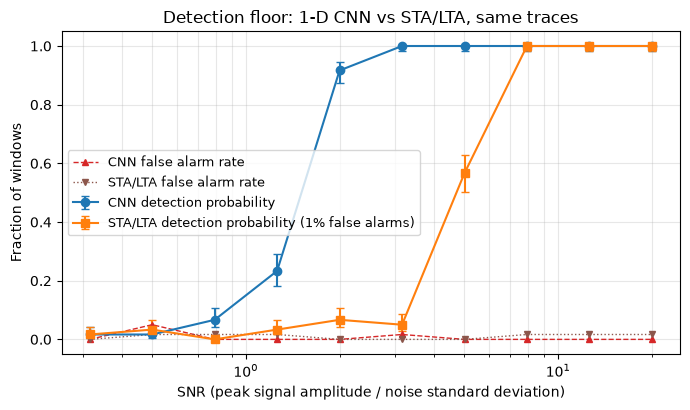

In [25]:
def binom_err(p, n):
    """Asymmetric Wilson error bars for an array of proportions."""
    lo, hi = np.array([wilson_interval(int(round(pi * n)), n) for pi in p]).T
    return p - lo, hi - p

cnn_lo, cnn_hi = binom_err(detect_prob, n_per)
sta_lo, sta_hi = binom_err(stalta_prob, n_per)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(snrs, detect_prob, yerr=[cnn_lo, cnn_hi], marker='o', capsize=3,
            label='CNN detection probability')
ax.errorbar(snrs, stalta_prob, yerr=[sta_lo, sta_hi], marker='s', capsize=3,
            color='tab:orange', label='STA/LTA detection probability (1% false alarms)')
ax.plot(snrs, false_alarm, color='tab:red', ls='--', lw=1, marker='^', ms=4,
        label='CNN false alarm rate')
ax.plot(snrs, stalta_fa, color='tab:brown', ls=':', lw=1, marker='v', ms=4,
        label='STA/LTA false alarm rate')
ax.set_xscale('log')
ax.set_xlabel('SNR (peak signal amplitude / noise standard deviation)')
ax.set_ylabel('Fraction of windows')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Detection floor: 1-D CNN vs STA/LTA, same traces')
ax.legend(loc='center left', fontsize=9)
ax.grid(alpha=0.3, which='both')
fig.tight_layout()

Lea primero las dos curvas en sus puntos de operación: las tasas de falsas alarmas punteadas son comparables (1 % anclado para STA/LTA, 0-5 % medido para la CNN), así que las curvas de detección pueden compararse directamente. Tres regímenes. Por debajo de SNR ≈ 0.8 los dos detectores coinciden en su piso de falsas alarmas — ningún algoritmo, aprendido o clásico, rescata una señal enterrada tan profundo en ruido del mismo color. Por encima de SNR ≈ 8 vuelven a coincidir, en 1.0: ahí el disparador clásico es la elección de ingeniería correcta, porque detecta todo sin costar nada entrenarlo, ajustarlo ni mantenerlo, y no puede derivar silenciosamente cuando la distribución de los datos cambia. La CNN se gana su complejidad solo en la banda intermedia: a SNR 2 detecta el 92 % de los eventos mientras que STA/LTA con el mismo presupuesto de falsas alarmas atrapa el 7 %, y su cruce del 50 % queda cerca de SNR 1.5 contra el cruce del disparador cerca de 5 — el mismo piso de STA/LTA que el experimento con ondículas de Ricker encontró en el [capítulo 2.10](../Chapter2-DataManipulation/2.10_synthetic_noise.ipynb) con una señal distinta y ruido real de espectro igualado. Aproximadamente media década de SNR es todo el territorio que gana el detector aprendido. Si ese territorio importa es una pregunta científica, no arquitectónica; en sismología resulta ser donde viven la mayoría de los sismos pequeños, y por eso los detectores aprendidos desplazaron a los disparadores de energía en la construcción de catálogos.

Este tipo de medición controlada es el argumento principal a favor de los *benchmarks* sintéticos: con datos reales solo se puede reportar el desempeño sobre los eventos que uno alcanzó a catalogar, y el catálogo mismo está sesgado en contra de los eventos de baja SNR.

**¿Por qué no correspondencia de plantillas?** Existe un método clásico que vence a ambos detectores a baja SNR: la **correspondencia de plantillas** (*template matching*), que correlaciona la forma de onda de un evento conocido contra los datos continuos y dispara sobre el coeficiente de correlación. Para una forma de onda conocida en ruido estacionario es el filtro adaptado (*matched filter*) — estadísticamente óptimo — y en la práctica detecta eventos repetitivos aproximadamente un orden de magnitud por debajo del piso de STA/LTA ([Gibbons & Ringdal, 2006](https://doi.org/10.1111/j.1365-246X.2006.02865.x)); así fue como se extrajeron los sismos de baja frecuencia del tremor ([Shelly et al., 2007](https://doi.org/10.1038/nature05666)). La trampa está en el nombre: necesita una plantilla, así que solo encuentra eventos que repiten una forma de onda que usted ya tiene — secuencias de réplicas, enjambres, sismos repetitivos, sismicidad inducida. Responde una pregunta más estrecha («¿volvió a romper *esta* fuente?») que los detectores de arriba («¿hay *algún* evento presente?»), y compararlo con justicia requeriría un conjunto de datos de fuentes repetitivas, razón por la cual queda fuera del alcance trabajado aquí.

**Ejercicio 2.** A partir de los resultados del barrido, estime la SNR a la cual la probabilidad de detección de la CNN cruza el 50 %, y lo mismo para STA/LTA. Luego reentrene el modelo con solo 2 épocas y vuelva a correr el barrido. ¿Se mueve el piso de detección de la CNN? ¿Y el de STA/LTA?

```{admonition} Solución
:class: dropdown
Lea los cruces en la tabla impresa o en la gráfica (puede interpolar con `np.interp(0.5, detect_prob, snrs)`, ya que las curvas son aproximadamente monótonas); la CNN cruza a una SNR más baja que el disparador clásico. Con solo 2 épocas de entrenamiento la red queda subentrenada: su transición se desplaza hacia SNR más altas y su meseta superior puede quedar por debajo de 1.0, así que su piso de detección sube. La curva de STA/LTA no se mueve en absoluto — no tiene parámetros que subentrenar, que es exactamente lo que la hace un modelo de referencia estable. Entrenar más tiempo, agregar datos o aumentar con ejemplos de baja SNR empuja el piso de la CNN hacia abajo, hasta el límite que fija el propio ruido.
```


## 6. Prueba de realidad: evaluar el detector sobre formas de onda reales de miniPNW

Todos los números hasta ahora se midieron sobre el mismo generador que produjo los datos de entrenamiento. La pregunta incómoda: ¿qué pasa con sismogramas reales?

El [capítulo 2.11](../Chapter2-DataManipulation/2.11_feature_engineering.ipynb) descargó **miniPNW**, un subconjunto etiquetado del *benchmark* listo para IA del Noroeste del Pacífico ([Ni et al., 2023](https://doi.org/10.26443/seismica.v2i1.368)): formas de onda reales con tiempos de llegada marcados por analistas (*picks*) y tipos de fuente. Evaluamos la CNN entrenada con sintéticos sobre unos cientos de ventanas de sismos reales, *sin cambios* — sin reentrenar, sin ajuste fino, sin mover el umbral. El preprocesamiento replica el del entrenamiento exactamente y nada más: una ventana de 30 s de la componente vertical, cortada de modo que el *pick* P quede a 7 s del inicio (dentro del rango que usaron los sintéticos), y luego la misma estandarización por traza. Las ventanas de ruido provienen de los primeros 30 s de cada traza, que terminan bien antes de la llegada P. Sea cual sea el resultado, lo reportamos.

In [26]:
import urllib.request
import h5py
import pandas as pd

# Same files and loader pattern as notebook 2.11, which caches them in its data/ folder
pnw_dir = os.path.join('..', 'Chapter2-DataManipulation', 'data')
os.makedirs(pnw_dir, exist_ok=True)
metadata_path = os.path.join(pnw_dir, 'miniPNW_metadata.csv')
waveform_path = os.path.join(pnw_dir, 'miniPNW_waveforms.hdf5')
base_url = 'https://dasway.ess.washington.edu/shared/niyiyu/PNW-ML'

have_pnw = True
try:
    if not os.path.exists(metadata_path):
        urllib.request.urlretrieve(f'{base_url}/miniPNW_metadata.csv', metadata_path)
    if not os.path.exists(waveform_path):
        print('Downloading miniPNW waveforms (about 670 MB, one-time; shared with notebook 2.11)...')
        urllib.request.urlretrieve(f'{base_url}/miniPNW_waveforms.hdf5', waveform_path)
except Exception as err:
    have_pnw = False
    print('miniPNW cache is missing and the download failed, so the reality check below is skipped.\n'
          'Run notebook 2.11 first (it downloads and caches the files), then rerun this section.\n'
          f'Reason: {err!r}')
have_pnw = have_pnw and os.path.exists(waveform_path)
print('miniPNW available:', have_pnw)

miniPNW available: True


In [27]:
if have_pnw:
    meta = pd.read_csv(metadata_path)
    eq = meta[(meta['source_type'] == 'earthquake') & meta['trace_P_arrival_sample'].notna()].copy()
    n_win, pre = 3000, 700  # 30 s at 100 Hz; P pick 7 s into the window
    p_samp = eq['trace_P_arrival_sample'].astype(int)
    # keep traces where the event window and a non-overlapping pre-P noise window both fit
    eq = eq[(p_samp - pre >= n_win) & (p_samp - pre + n_win <= 15001)].head(300)

    def read_z(f, trace_name):
        """Vertical component of one miniPNW trace (same reader as notebook 2.11)."""
        bucket, narray = trace_name.split('$')
        x, _, z = (int(v) for v in narray.split(',:'))
        return f['/data/' + bucket][x, 2, :z]  # channel order N, E, Z

    X_real_ev = np.zeros((len(eq), n_win), dtype=np.float64)
    X_real_no = np.zeros((len(eq), n_win), dtype=np.float64)
    snr_db = np.zeros(len(eq))
    with h5py.File(waveform_path, 'r') as f:
        for i, (_, row) in enumerate(eq.iterrows()):
            tr = read_z(f, row['trace_name']).astype(np.float64)
            pk = int(row['trace_P_arrival_sample'])
            X_real_ev[i] = tr[pk - pre : pk - pre + n_win]
            X_real_no[i] = tr[:n_win]  # the trace starts 50 s before the pick: pre-event noise
            snr_db[i] = np.mean([float(v) for v in str(row['trace_snr_db']).split('|')])

    # drop dead windows (flat traces cannot be standardized)
    alive = (X_real_ev.std(axis=1) > 0) & (X_real_no.std(axis=1) > 0)
    X_real_ev, X_real_no, snr_db = X_real_ev[alive], X_real_no[alive], snr_db[alive]
    print(f"real earthquake windows: {len(X_real_ev)}, matched pre-event noise windows: {len(X_real_no)}")

real earthquake windows: 300, matched pre-event noise windows: 300


synthetic test accuracy (Section 5.3):        87.9%
real miniPNW detection rate (earthquakes):    86.3%
real miniPNW false alarm rate (pre-P noise):  92.7%
real miniPNW balanced accuracy:               46.8%
synthetic-to-real gap (balanced accuracy):    41.1 percentage points
catalog SNR -12.1 to   1.7 dB: detection rate 0.99
catalog SNR   1.7 to   4.8 dB: detection rate 0.85
catalog SNR   4.8 to  11.2 dB: detection rate 0.80
catalog SNR  11.2 to  59.1 dB: detection rate 0.81


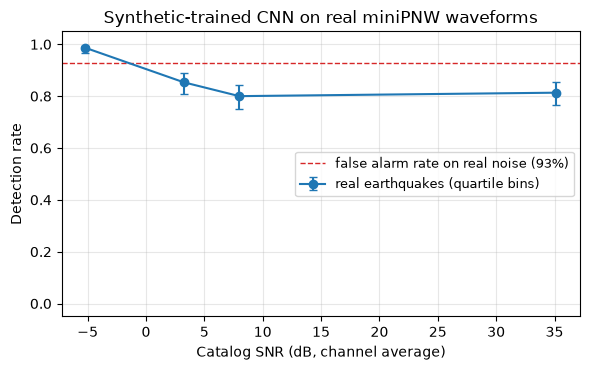

In [28]:
if have_pnw:
    pred_real_ev = predict(model_seis, standardize(X_real_ev))
    pred_real_no = predict(model_seis, standardize(X_real_no))
    real_det = pred_real_ev.mean()
    real_fa = pred_real_no.mean()
    real_acc = 0.5 * (real_det + (1 - real_fa))

    print(f"synthetic test accuracy (Section 5.3):        {100 * test_acc:.1f}%")
    print(f"real miniPNW detection rate (earthquakes):    {100 * real_det:.1f}%")
    print(f"real miniPNW false alarm rate (pre-P noise):  {100 * real_fa:.1f}%")
    print(f"real miniPNW balanced accuracy:               {100 * real_acc:.1f}%")
    print(f"synthetic-to-real gap (balanced accuracy):    "
          f"{100 * (test_acc - real_acc):.1f} percentage points")

    # detection rate vs catalog SNR (quartile bins), with binomial error bars
    edges = np.quantile(snr_db, [0, 0.25, 0.5, 0.75, 1.0])
    centers, det_b, err_b = [], [], []
    for a, b in zip(edges[:-1], edges[1:]):
        m = (snr_db >= a) & (snr_db <= b)
        k, n = int(pred_real_ev[m].sum()), int(m.sum())
        lo, hi = wilson_interval(k, n)
        centers.append(0.5 * (a + b))
        det_b.append(k / n)
        err_b.append((k / n - lo, hi - k / n))
    err_b = np.array(err_b).T
    for ctr, d, (a, b) in zip(centers, det_b, zip(edges[:-1], edges[1:])):
        print(f"catalog SNR {a:5.1f} to {b:5.1f} dB: detection rate {d:.2f}")

    fig, ax = plt.subplots(figsize=(6, 3.8))
    ax.errorbar(centers, det_b, yerr=err_b, marker='o', capsize=3, color='tab:blue',
                label='real earthquakes (quartile bins)')
    ax.axhline(real_fa, color='tab:red', ls='--', lw=1,
               label=f'false alarm rate on real noise ({100 * real_fa:.0f}%)')
    ax.set_xlabel('Catalog SNR (dB, channel average)')
    ax.set_ylabel('Detection rate')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('Synthetic-trained CNN on real miniPNW waveforms')
    ax.legend(loc='center right', fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()

La brecha es el resultado: 87.9 % de exactitud balanceada en trazas de prueba sintéticas, 46.8 % en ventanas reales de miniPNW — nivel de azar, una caída de 41 puntos porcentuales. El modo de falla es específico y vale la pena nombrarlo. Las ventanas de sismos reales se marcan al 86 %, lo que parece respetable visto en aislamiento, pero el detector también marca como sismos el 93 % de las ventanas reales de *ruido previo al evento*. La curva por intervalos de SNR dice lo mismo con más filo: la detección es *más alta* (99 %) en el cuartil de SNR más bajo, donde la ventana es mayormente ruido, y la curva completa es indistinguible de la tasa de falsas alarmas. La red no está respondiendo a los sismos en absoluto. Aprendió «evento sintético contra el único modelo de ruido sintético con el que fue entrenada», y el ruido real del Noroeste del Pacífico — no estacionario, dominado por el microsismo oceánico — no se parece a ninguno de los dos, así que casi todo dispara.

Reportamos este número tal como se midió: sin un filtro pasabanda elegido para arreglarlo, sin reentrenamiento, sin mover el umbral después de ver los datos de prueba. Ajustar la brecha hasta hacerla desaparecer borraría la lección, que es la regla de admisibilidad del [capítulo 2.10](../Chapter2-DataManipulation/2.10_synthetic_noise.ipynb) hecha concreta: **un modelo validado solo con datos sintéticos no ha sido validado**, y así es como se ve esa oración convertida en medición. Cerrar la brecha exige datos reales del lado del entrenamiento — entrenar o hacer ajuste fino con formas de onda etiquetadas de miniPNW (están ahí, en la caché), o hacer que el ruido del generador sea informado por la física, con el ruido de espectro igualado de 2.10. El cuaderno [4.6](mlgeo_4.6_AutoEncoder.ipynb) corre el experimento compañero: cuánto de un *codificador* preentrenado con sintéticos sobrevive al contacto con los mismos datos reales.

## 7. Cómo leer y recodificar redes publicadas

Suponga que un artículo de investigación describe la arquitectura de la CNN que los autores usaron para su análisis, pero no proporciona código. ¿Cómo la reproduciría?

Considere este artículo:

Rouet-Leduc, B., Hulbert, C., McBrearty, I. W., Johnson, P. A. (2020). Probing slow earthquakes with deep learning. Geophysical Research Letters, 47, e2019GL085870. [https://doi.org/10.1029/2019GL085870](https://doi.org/10.1029/2019GL085870)

(La figura 1 de Rouet-Leduc et al. (2020) muestra la arquitectura de la red; vea el artículo en https://doi.org/10.1029/2019GL085870 — la figura no se reproduce aquí por razones de licencia.)

Esquema de la CNN y su arquitectura (figura 1 de Rouet-Leduc et al., 2020).

Leyendo el artículo y su material suplementario, podemos listar las capas:

* **Entrada**: imagen de espectrograma de 129 x 95 x 1 píxeles
* **Conv2D**: tamaño de kernel 16 x 16, profundidad 32 (número de canales), que produce mapas de características de tamaño 114 x 80; activación ReLU (encontrada en el material suplementario)
* **Max pooling** de tamaño 2
* **Dropout** de 5 % (encontrado en el material suplementario)
* **Conv2D**: tamaño de kernel 8 x 8, profundidad 64
* **Max pooling** de tamaño 2
* **Dropout** de 5 % (encontrado en el material suplementario)
* **Conv2D**: tamaño de kernel 4 x 4, profundidad 128
* **Capa totalmente conectada (densa)** que aplana a 36 608 valores (encontrada en el material suplementario)
* **Capa totalmente conectada (densa)** con 10 neuronas
* **Capa totalmente conectada (densa)** con 1 neurona, activación sigmoide, que da la probabilidad de que la ventana contenga tremor

Ahora traducimos esa lista, línea por línea, a una pila `torch.nn.Sequential`:


In [29]:
model_tremor = torch.nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=16),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout(0.05),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=8),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout(0.05),
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4),
    nn.Flatten(),
    nn.Linear(36608, 10),
    nn.Sigmoid(),
    nn.Linear(10, 1),
    nn.Sigmoid(),
)

Para verificar la traducción, ejecutamos una pasada hacia adelante sobre un tensor de prueba con la forma de entrada del artículo, `(batch, channels, height, width) = (1, 1, 129, 95)`, e inspeccionamos la forma después de cada capa:


In [30]:
Xd = torch.randn(1, 1, 129, 95)
print('Input shape: \t\t', Xd.shape)
for layer in model_tremor:
    Xd = layer(Xd)
    print(layer.__class__.__name__, 'output shape: \t', Xd.shape)

Input shape: 		 torch.Size([1, 1, 129, 95])
Conv2d output shape: 	 torch.Size([1, 32, 114, 80])
ReLU output shape: 	 torch.Size([1, 32, 114, 80])
MaxPool2d output shape: 	 torch.Size([1, 32, 57, 40])
Dropout output shape: 	 torch.Size([1, 32, 57, 40])
Conv2d output shape: 	 torch.Size([1, 64, 50, 33])
ReLU output shape: 	 torch.Size([1, 64, 50, 33])
MaxPool2d output shape: 	 torch.Size([1, 64, 25, 16])
Dropout output shape: 	 torch.Size([1, 64, 25, 16])
Conv2d output shape: 	 torch.Size([1, 128, 22, 13])
Flatten output shape: 	 torch.Size([1, 36608])
Linear output shape: 	 torch.Size([1, 10])
Sigmoid output shape: 	 torch.Size([1, 10])
Linear output shape: 	 torch.Size([1, 1])
Sigmoid output shape: 	 torch.Size([1, 1])


In [31]:
torchinfo.summary(model_tremor, input_size=(1, 1, 129, 95))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Conv2d: 1-1                            [1, 32, 114, 80]          8,224
├─ReLU: 1-2                              [1, 32, 114, 80]          --
├─MaxPool2d: 1-3                         [1, 32, 57, 40]           --
├─Dropout: 1-4                           [1, 32, 57, 40]           --
├─Conv2d: 1-5                            [1, 64, 50, 33]           131,136
├─ReLU: 1-6                              [1, 64, 50, 33]           --
├─MaxPool2d: 1-7                         [1, 64, 25, 16]           --
├─Dropout: 1-8                           [1, 64, 25, 16]           --
├─Conv2d: 1-9                            [1, 128, 22, 13]          131,200
├─Flatten: 1-10                          [1, 36608]                --
├─Linear: 1-11                           [1, 10]                   366,090
├─Sigmoid: 1-12                          [1, 10]                   

Dos verificaciones contra el artículo: la primera convolución produce mapas de características de 114 x 80, exactamente como se afirma, y el vector aplanado que entra a las capas densas tiene 128 x 22 x 13 = 36 608 valores, lo que coincide con las «36 608 neuronas» del material suplementario. Cuando estos números cuadran, la recodificación es consistente con la tabla publicada.

Note que **no** entrenamos esta red. El ejercicio aquí es traducir la descripción de una arquitectura publicada a código funcional y verificarla contra las formas y los conteos de parámetros reportados en el artículo. Entrenarla requeriría el conjunto de datos del artículo (años de datos sísmicos y de GPS continuos de Cascadia) y un cómputo considerable; este curso no tiene ninguna de las dos cosas, y ninguna hace falta para aprender la habilidad.


## 8. Ajuste de redes CNN

Hay muchos hiperparámetros y decisiones de modelo que tomar:

* Entrenamiento: tasa de aprendizaje, optimizador, tamaño de lote, función de pérdida, regularización
* Arquitectura: número de capas, número de canales (profundidad) por capa, tamaños de kernel, funciones de activación, normalización por lotes, *dropout*

Volvemos al ajuste sistemático de hiperparámetros, incluida la búsqueda automatizada con Optuna, en el cuaderno 4.5 (entrenamiento de modelos).

## Resumen

* Una convolución desliza un kernel pequeño sobre la entrada; los kernels diseñados a mano difuminan o detectan bordes, y una CNN aprende sus kernels a partir de los datos.
* Un bloque de CNN es convolución, activación, *pooling*; una cabeza de clasificación es una o más capas totalmente conectadas.
* LeNet-5 en PyTorch es una docena de líneas; un detector de sismos con CNN 1D es aún más pequeño.
* Sobre un campo climático en malla, una CNN 2D pequeña supera por un factor de diez la estimación ingenua de tendencias por mínimos cuadrados — pero solo porque aprendió el modo interanual de confusión del generador; dele al ajuste clásico ese modo como un regresor y los dos empatan en ~0.01 °C/década.
* Medidos sobre las mismas trazas a tasas de falsas alarmas comparables, STA/LTA cruza el 50 % de detección cerca de SNR 5 y la CNN cerca de 1.5; la banda intermedia es todo el caso a favor del detector aprendido.
* Evaluado sin cambios sobre formas de onda reales de miniPNW, el detector entrenado con sintéticos cae de 87.9 % a 46.8 % de exactitud balanceada — azar — porque el ruido real, rico en microsismo, lo dispara constantemente. La brecha sintético-real es la medición; la validación solo con sintéticos no es validación.
* La tabla de arquitectura de una publicación, más las verificaciones de formas con `torchinfo.summary`, basta para recodificar una red de la que no se tiene código fuente.

A continuación: redes recurrentes para datos secuenciales en el cuaderno 4.4.
